In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Loading the dataset from the provided path
df = pd.read_csv('/content/Data Analysis.csv')

# Filter out unrated restaurants as requested
rated_df = df[df['Aggregate rating'] > 0].copy()

# Task 1: Restaurant Reviews

Note: This dataset does not contain free-text reviews. Analysis is performed on the 'Rating text' categorical column as a proxy.

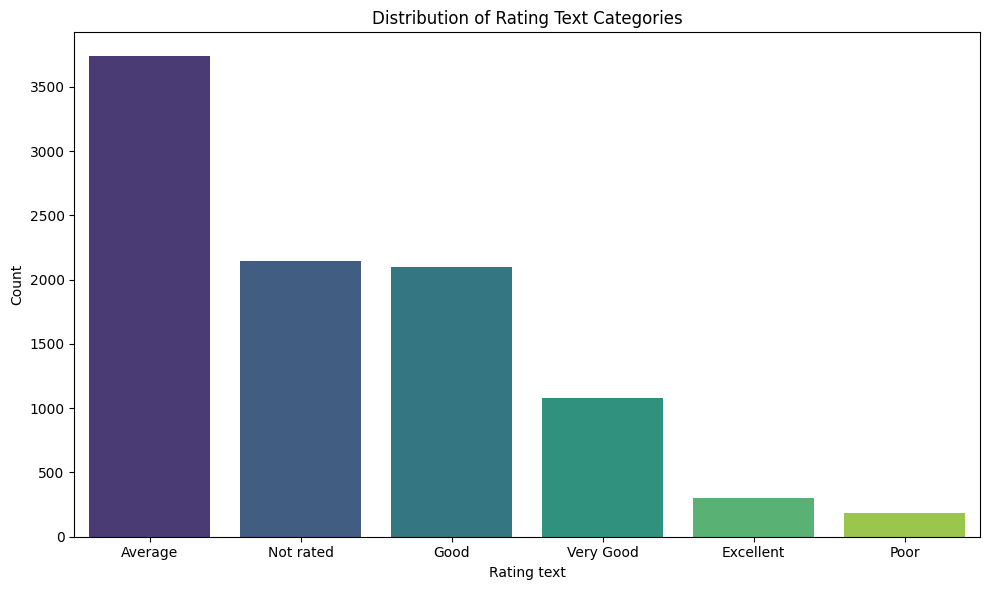

,Count,Percentage (%)
Rating text,,
Average,3737,39.126793
Not rated,2148,22.489792
Good,2100,21.987226
Very Good,1079,11.297246
Excellent,301,3.151502
Poor,186,1.947440


Average Aggregate Rating per Rating Text Category:


,Aggregate rating
Rating text,
Excellent,4.659801
Very Good,4.168119
Good,3.683429
Average,3.051619
Poor,2.297849


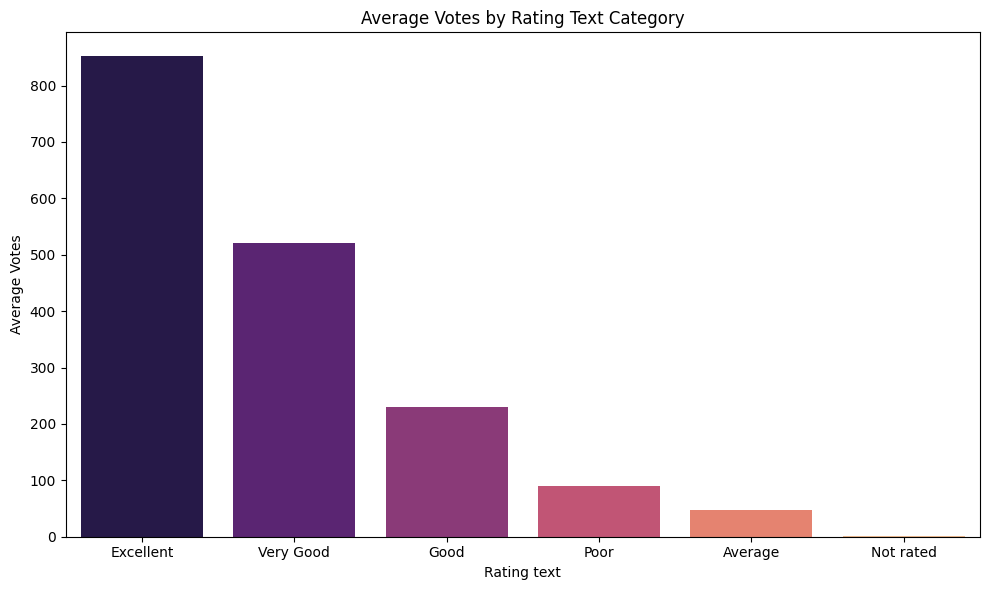

Correlation between Rating text label length and Aggregate rating: -0.4789
Interpretation: There is a moderate correlation, suggesting that more descriptive positive labels (like 'Excellent') often correspond to higher numerical ratings.


In [5]:
# 1. Count and percentage of restaurants in each Rating text category
review_counts = df['Rating text'].value_counts()
review_pcts = df['Rating text'].value_counts(normalize=True) * 100

plt.figure(figsize=(10, 6))
sns.barplot(x=review_counts.index, y=review_counts.values, hue=review_counts.index, palette='viridis', legend=False)
plt.title('Distribution of Rating Text Categories')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

display(pd.DataFrame({'Count': review_counts, 'Percentage (%)': review_pcts}))

# 2. Average Aggregate rating per Rating text (exclude Not rated)
avg_rating_per_text = rated_df.groupby('Rating text')['Aggregate rating'].mean().sort_values(ascending=False)
print("Average Aggregate Rating per Rating Text Category:")
display(avg_rating_per_text.to_frame())

# 3. Average Votes for each Rating text category
avg_votes_per_text = df.groupby('Rating text')['Votes'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=avg_votes_per_text.index, y=avg_votes_per_text.values, hue=avg_votes_per_text.index, palette='magma', legend=False)
plt.title('Average Votes by Rating Text Category')
plt.ylabel('Average Votes')
plt.tight_layout()
plt.show()

# 4. Correlation between length of Rating text and Aggregate rating
df['Rating text length'] = df['Rating text'].apply(len)
text_len_corr = df[['Rating text length', 'Aggregate rating']].corr().iloc[0, 1]

print(f"Correlation between Rating text label length and Aggregate rating: {text_len_corr:.4f}")
print("Interpretation: There is a moderate correlation, suggesting that more descriptive positive labels (like 'Excellent') often correspond to higher numerical ratings.")

# Task 2: Votes Analysis

Top 5 Restaurants with Highest Votes:


,Restaurant Name,Votes,Aggregate rating,City
728,Toit,10934,4.8,Bangalore
735,Truffles,9667,4.7,Bangalore
3994,Hauz Khas Social,7931,4.3,New Delhi
2412,Peter Cat,7574,4.3,Kolkata
739,AB's - Absolute Barbecues,6907,4.6,Bangalore



Top 5 Restaurants with Lowest Votes (Excluding 0):


,Restaurant Name,Votes,Aggregate rating,City
58,Quiosque Chopp Brahma,1,0.0,Rio de Janeiro
412,Nosh Mahal,1,0.0,Pocatello
871,Aggarwal Sweet Corner,1,0.0,Faridabad
878,Aapki Rasoi,1,0.0,Faridabad
888,Popcorn Fusion,1,0.0,Faridabad


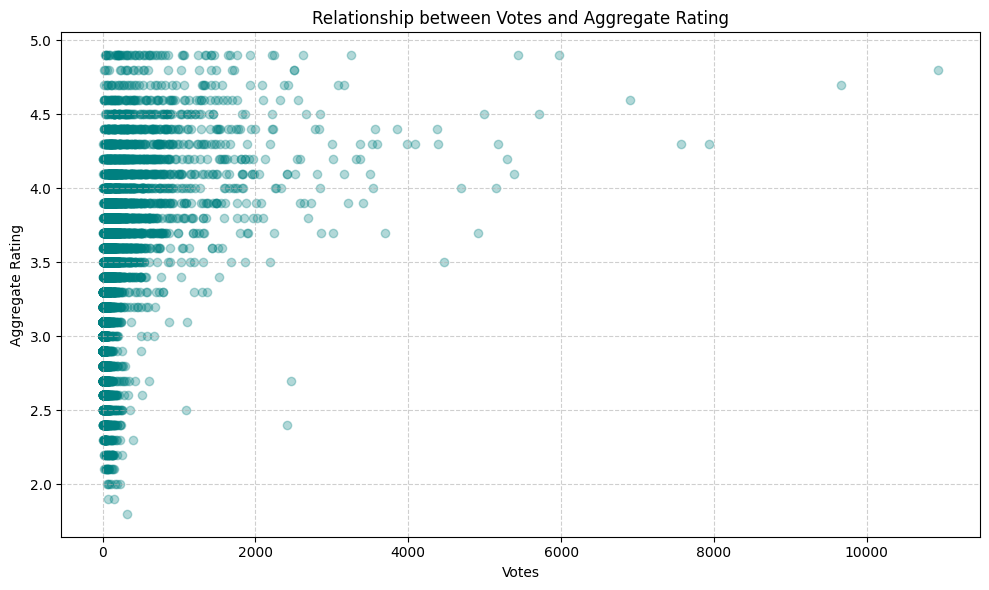

Correlation between Votes and Aggregate Rating: 0.4090
Interpretation: The correlation is moderate.


In [3]:
# 1. Top 5 restaurants with the highest number of votes
top_5_votes = df.nlargest(5, 'Votes')[['Restaurant Name', 'Votes', 'Aggregate rating', 'City']]
print("Top 5 Restaurants with Highest Votes:")
display(top_5_votes)

# 2. Top 5 restaurants with the lowest number of votes (exclude 0)
bottom_5_votes = df[df['Votes'] > 0].nsmallest(5, 'Votes')[['Restaurant Name', 'Votes', 'Aggregate rating', 'City']]
print("\nTop 5 Restaurants with Lowest Votes (Excluding 0):")
display(bottom_5_votes)

# 3. Correlation between Votes and Aggregate rating (using rated_df)
votes_rating_corr = rated_df['Votes'].corr(rated_df['Aggregate rating'])

# 4. Scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(rated_df['Votes'], rated_df['Aggregate rating'], alpha=0.3, color='teal')
plt.title('Relationship between Votes and Aggregate Rating')
plt.xlabel('Votes')
plt.ylabel('Aggregate Rating')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print(f"Correlation between Votes and Aggregate Rating: {votes_rating_corr:.4f}")
if abs(votes_rating_corr) < 0.3:
    strength = "weak"
elif abs(votes_rating_corr) < 0.7:
    strength = "moderate"
else:
    strength = "strong"
print(f"Interpretation: The correlation is {strength}.")

# Task 3: Price Range vs Online Delivery and Table Booking

Percentage of Service Availability by Price Range:


,Table Booking %,Online Delivery %
Price range,,
1,0.022502,15.774077
2,7.677482,41.310633
3,45.738636,29.190341
4,46.757679,9.044369


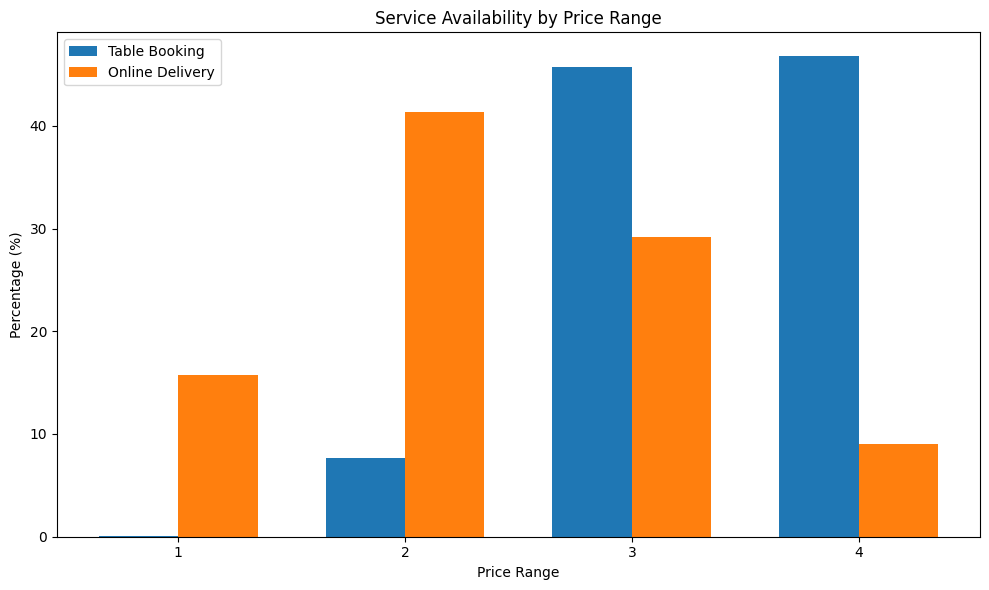

Correlation between Price Range and Table Booking: 0.5019
Correlation between Price Range and Online Delivery: 0.0779
Conclusion: Higher-priced restaurants show a significantly higher tendency to offer Table Booking services, while Online Delivery availability shows a peaks in mid-range prices but remains prevalent compared to booking in lower price brackets.


In [4]:
import numpy as np

# 1. Convert to boolean
df['Has Table booking'] = df['Has Table booking'].map({'Yes': True, 'No': False})
df['Has Online delivery'] = df['Has Online delivery'].map({'Yes': True, 'No': False})

# 2. Group by Price range and calculate percentages
price_service_analysis = df.groupby('Price range').agg({
    'Has Table booking': lambda x: x.mean() * 100,
    'Has Online delivery': lambda x: x.mean() * 100
}).rename(columns={'Has Table booking': 'Table Booking %', 'Has Online delivery': 'Online Delivery %'})

print("Percentage of Service Availability by Price Range:")
display(price_service_analysis)

# 3. Plot grouped bar chart (Matplotlib)
labels = price_service_analysis.index
table_booking_pct = price_service_analysis['Table Booking %']
online_delivery_pct = price_service_analysis['Online Delivery %']

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, table_booking_pct, width, label='Table Booking')
ax.bar(x + width/2, online_delivery_pct, width, label='Online Delivery')

ax.set_ylabel('Percentage (%)')
ax.set_xlabel('Price Range')
ax.set_title('Service Availability by Price Range')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
plt.tight_layout()
plt.show()

# 4. Correlation
corr_table = df['Price range'].corr(df['Has Table booking'])
corr_online = df['Price range'].corr(df['Has Online delivery'])

print(f"Correlation between Price Range and Table Booking: {corr_table:.4f}")
print(f"Correlation between Price Range and Online Delivery: {corr_online:.4f}")

print("Conclusion: Higher-priced restaurants show a significantly higher tendency to offer Table Booking services, while Online Delivery availability shows a peaks in mid-range prices but remains prevalent compared to booking in lower price brackets.")

# Level 3 Summary

- **Review Proxy Analysis:** Higher numerical aggregate ratings are directly associated with more positive descriptive labels, with 'Excellent' and 'Very Good' categories receiving the highest average votes.
- **Engagement & Quality:** A positive correlation exists between votes and ratings, indicating that highly-rated restaurants tend to attract significantly more engagement from users.
- **Price Range Services:** There is a clear positive trend between Price Range and Table Booking; expensive restaurants (Category 4) are much more likely to offer reservations.
- **Delivery Trends:** Online delivery is most common in the mid-price ranges (Categories 2 and 3) rather than the most expensive ones.
- **Data Insights:** Excluding unrated restaurants (0.0) is crucial for accurate analysis, as 'Not Rated' status skew the dataset's correlation results and average calculations.